# 4.3 — The Normal Distribution, at the computer

Do the **pen-and-paper worksheet first**. This notebook holds the best magic trick in the module:
you'll build a bell curve out of *nothing but flat, boring randomness* — the same law that makes
diffusion models possible.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## 1. 🌀 The bell curve, born from chaos

One die is perfectly flat — every face equally likely. No bell anywhere in sight.
Now **add dice together** and watch what the sums do:

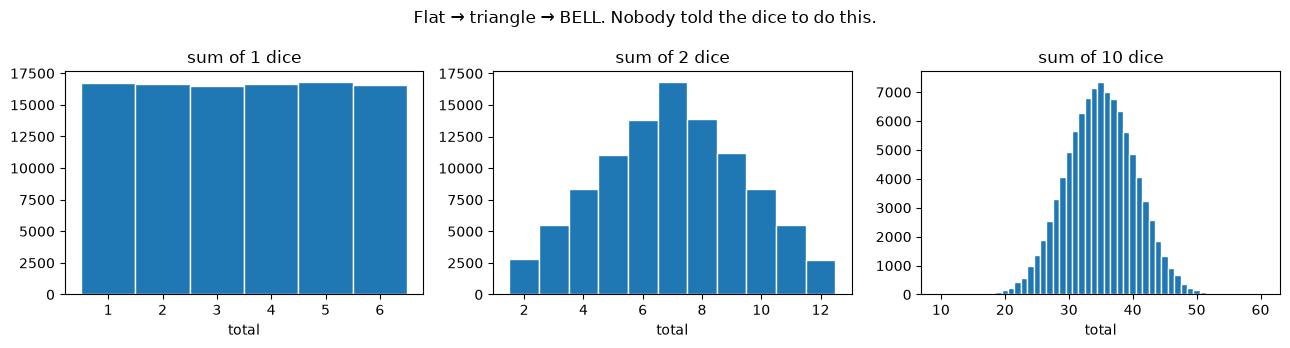

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))   # three panels in a row

for ax, n_dice in zip(axes, [1, 2, 10]):            # zip pairs each panel with a dice-count
    rolls = rng.integers(1, 7, size=(100_000, n_dice))
    sums = rolls.sum(axis=1)                        # add across each row: total of n_dice dice
    ax.hist(sums, bins=np.arange(n_dice - 0.5, 6 * n_dice + 1.5), edgecolor="white")
    ax.set_title(f"sum of {n_dice} dice")
    ax.set_xlabel("total")

plt.suptitle("Flat → triangle → BELL. Nobody told the dice to do this.")
plt.tight_layout()
plt.show()

Sit with that middle-to-right transition for a second. Each die is memoryless, flat, lawless —
yet their *sum* obeys a strict, universal shape. Add up many small independent random things and
the bell **always** emerges: dice, coin flips, measurement errors, human heights. Randomness in,
law out. (This is the central limit theorem, and you just proved it the physicist's way.)

## 2. `rng.normal` and the 68/95/99.7 rule, on trial

numpy can draw straight from the bell: `rng.normal(mu, sigma, size)`. The worksheet's rule
claims fixed fractions within 1, 2, 3 σ — count them:

within 1σ of the mean: 0.6831
within 2σ of the mean: 0.9545
within 3σ of the mean: 0.9973


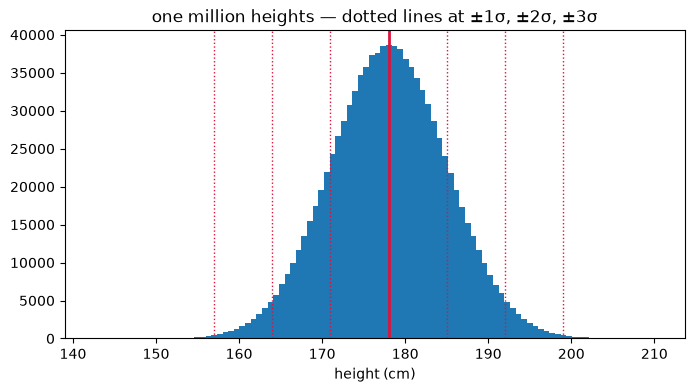

In [3]:
mu, sigma = 178, 7                                  # adult male heights, in cm
heights = rng.normal(mu, sigma, size=1_000_000)

for k in [1, 2, 3]:
    inside = (np.abs(heights - mu) < k * sigma).mean()   # |x - mu| < k*sigma, as a fraction
    print(f"within {k}\u03c3 of the mean: {inside:.4f}")   # :.4f = show 4 decimal places

plt.figure(figsize=(8, 4))
plt.hist(heights, bins=100, edgecolor="none")
for k in [-3, -2, -1, 1, 2, 3]:
    plt.axvline(mu + k * sigma, color="crimson", linestyle=":", linewidth=1)
plt.axvline(mu, color="crimson", linewidth=2)
plt.title("one million heights — dotted lines at \u00b11\u03c3, \u00b12\u03c3, \u00b13\u03c3")
plt.xlabel("height (cm)")
plt.show()

0.68…, 0.95…, 0.997… — the rule holds to the third decimal. Not bad for a claim about pure chance.

## 3. μ and σ are the shift and stretch dials (Module 1.3 pays off)

Every normal is the standard $\mathcal{N}(0,1)$, shifted by μ and stretched by σ — literally
$x = \mu + \sigma z$:

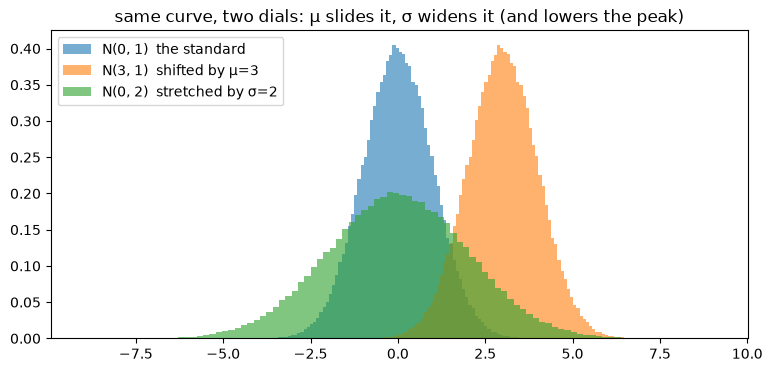

In [4]:
z = rng.normal(0, 1, size=200_000)                   # the standard normal — ML's noise source

plt.figure(figsize=(9, 4))
# density=True rescales bar heights so the AREA totals 1 — comparing shapes, not raw counts.
# alpha=0.6 makes bars see-through so the three curves can overlap.
plt.hist(z,         bins=100, density=True, alpha=0.6, label="N(0, 1)  the standard")
plt.hist(3 + z,     bins=100, density=True, alpha=0.6, label="N(3, 1)  shifted by \u03bc=3")
plt.hist(2 * z,     bins=100, density=True, alpha=0.6, label="N(0, 2)  stretched by \u03c3=2")
plt.legend()
plt.title("same curve, two dials: \u03bc slides it, \u03c3 widens it (and lowers the peak)")
plt.show()

In [5]:
# YOUR TURN
#
# a) Worksheet check — lesson example: what fraction of heights lie between 171 and 192?
#    You computed 81.5% by half-bands. The jury of one million:
print(((heights > 171) & (heights < 192)).mean())    # & = both conditions true

# b) Worksheet problem 10 (fraction of men taller than the 192 cm doorway) — one line, write it:

# c) Build N(100, 15) IQ scores from the STANDARD normal z above, using only * and +
#    (the two dials — no new rng.normal call allowed!). Prove it with .mean() and .std():
# iq = ...

# d) The stretch dial in reverse: what fraction of your iq scores are above 130? Above 145?

0.819213


## 4. Why diffusion models care

Stable Diffusion's training loop, one line of which you can now read:
$x_{\text{noisy}} = x + \sigma\,\varepsilon$ where $\varepsilon \sim \mathcal{N}(0, 1)$ —
*take the image, add stretched standard-normal noise*. Turn σ up step by step and the image
drowns in the bell curve; the model's whole job is learning to swim back. Module 6.6 runs this
on a real photo — every symbol will already be yours.

---
*Done? Photograph your worksheet into `scans/inbox/` and tell Claude. Next: 4.4 — samples,
seeds, and why training is random on purpose.*